In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff


In [ ]:
data = arff.loadarff('/content/drive/MyDrive/Hasan sir/new_analysis/maxwell.arff')
df = pd.DataFrame(data[0])
df.head()

,Syear,App,Har,Dba,Ifc,Source,Telonuse,Nlan,T01,T02,...,T10,T11,T12,T13,T14,T15,Duration,Size,Time,Effort
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,5.0,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0
1,93.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,2.0,3.0,...,3.0,4.0,4.0,4.0,4.0,4.0,5.0,130.0,9.0,845.0
2,90.0,1.0,2.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,...,5.0,4.0,3.0,2.0,3.0,3.0,8.0,254.0,6.0,2330.0
3,86.0,3.0,2.0,1.0,2.0,2.0,0.0,3.0,2.0,2.0,...,4.0,5.0,4.0,3.0,2.0,3.0,16.0,1056.0,2.0,21272.0
4,88.0,2.0,2.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,...,4.0,3.0,4.0,5.0,4.0,4.0,12.0,383.0,4.0,4224.0


In [ ]:
df.describe()

,Syear,App,Har,Dba,Ifc,Source,Telonuse,Nlan,T01,T02,...,T10,T11,T12,T13,T14,T15,Duration,Size,Time,Effort
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,...,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,89.580645,2.354839,2.612903,1.032258,1.935484,1.870968,0.241935,2.548387,3.048387,3.048387,...,3.612903,3.419355,3.822581,3.064516,3.258065,3.338710,17.209677,673.306452,5.580645,8223.209677
std,2.131331,0.993368,0.997617,0.442339,0.247676,0.337972,0.431751,1.019119,0.998809,0.711208,...,0.893599,0.984276,0.690075,0.955930,1.007114,0.745336,10.651156,784.084505,2.131331,10499.903168
min,85.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,4.000000,48.000000,1.000000,583.000000
25%,88.000000,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,2.000000,2.000000,3.000000,...,3.000000,3.000000,4.000000,2.000000,3.000000,3.000000,10.000000,232.500000,4.000000,2388.750000
50%,90.000000,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,3.000000,3.000000,3.000000,...,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,13.500000,385.000000,6.000000,5189.500000
75%,91.000000,3.000000,3.000000,1.000000,2.000000,2.000000,0.000000,3.000000,4.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,23.500000,640.750000,7.000000,9308.000000
max,93.000000,5.000000,5.000000,4.000000,2.000000,2.000000,1.000000,4.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,54.000000,3643.000000,9.000000,63694.000000


<Axes: title={'center': 'Pearson Correlation of Features'}>

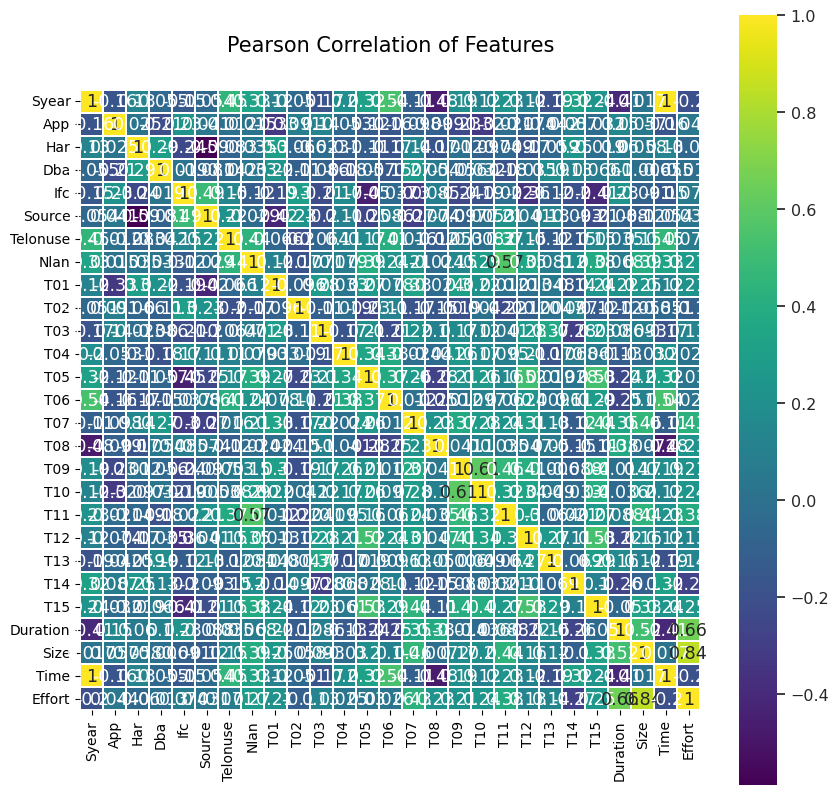

In [ ]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [ ]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

Syear       1.000000
Time        1.000000
Size        0.841805
Effort      0.841805
Duration    0.656883
T10         0.605523
T09         0.605523
dtype: float64

In [ ]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['Syear', 'Time', 'Size','Effort','Duration', 'T10','T09']

X = df[max_corr_features]
y = df['Effort']

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [ ]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=9, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

Root mean square:  1058.4417881222398
Mean Absolute error 558.7251461988303


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 558.73
Mean Squared Error (MSE): 1120299.02
Root Mean Squared Error (RMSE): 1058.44
R-squared (R²): 0.94
mape: 7.18


In [ ]:
import matplotlib.pyplot as plot
import pandas

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

In [ ]:
Y_Train.shape

(43,)

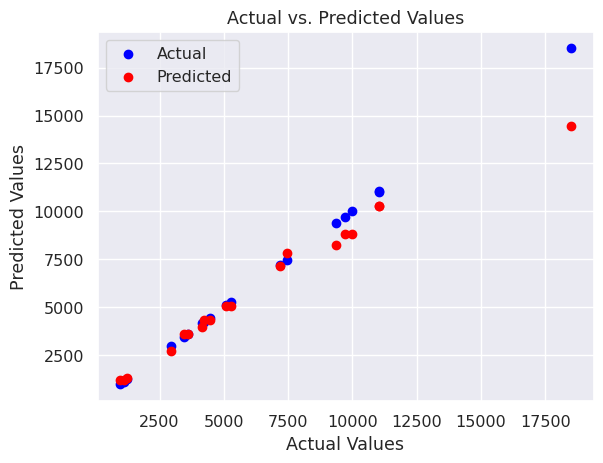

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [ ]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

Root mean square:  4.14228870707501e-12
Mean Absolute error 3.6140447359924255e-12


In [ ]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


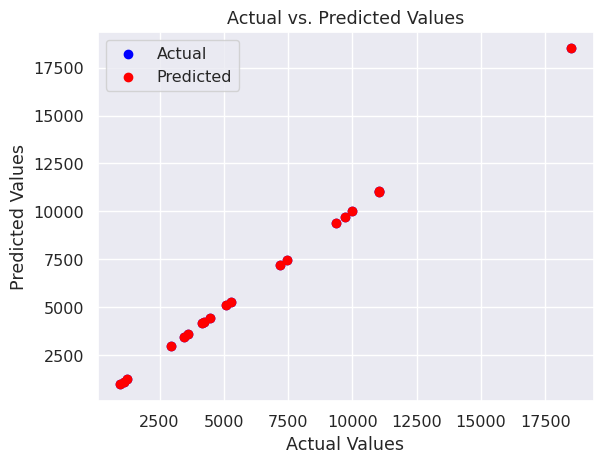

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [ ]:

    regressor = RandomForestRegressor(n_estimators=100,max_features=5)
    regressor.fit(X_Train, Y_Train)
    predict_RF = regressor.predict(X_Test)
    print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
    print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  1422.5147259602213
Mean Absolute error 629.2142105263159


In [ ]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 629.21
Mean Squared Error (MSE): 2023548.15
Root Mean Squared Error (RMSE): 1422.51
R-squared (R²): 0.89
mape: 10.19


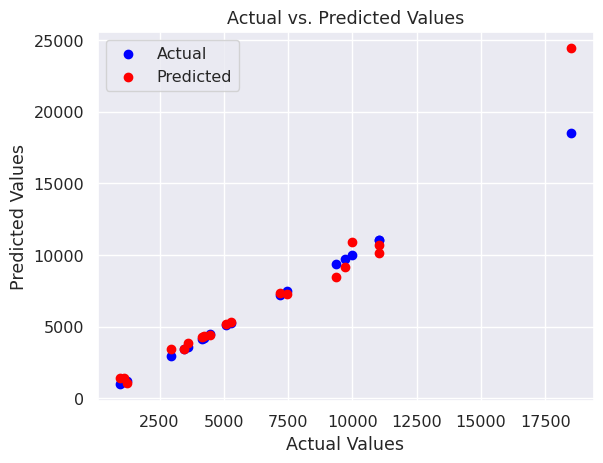

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***SVM***

In [ ]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  0.06398314525711063
Mean Absolute error 0.052156243463119416


In [ ]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.05
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.06
R-squared (R²): 1.00
mape: 0.00


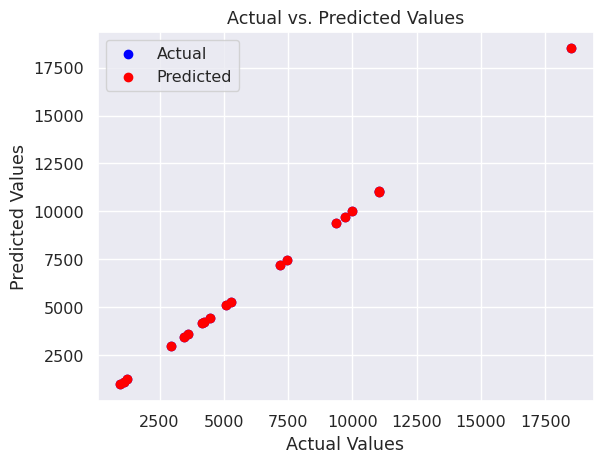

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***lasso***

In [ ]:
from sklearn import linear_model

In [ ]:
clf = linear_model.Lasso(alpha=0.1)

In [ ]:
clf.fit(X_Train, Y_Train)

Lasso(alpha=0.1)

In [ ]:
print(clf.coef_)

[-0.00000000e+00 -0.00000000e+00  1.21389138e-04  9.99992656e-01
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]


In [ ]:
print(clf.intercept_)

-0.018090513225615723


In [ ]:
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

Root mean square:  0.06090392420360484
Mean Absolute error 0.03819099326927986


In [ ]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.04
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.06
R-squared (R²): 1.00
mape: 0.00


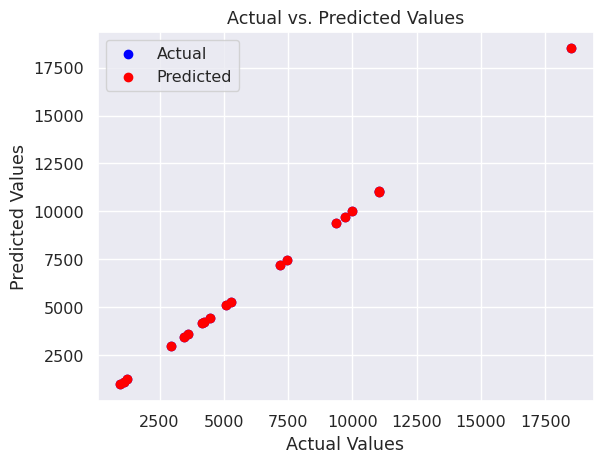

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()